# Project Overview

This project aims to build a complete end-to-end Machine Learning pipeline to predict the price of used bikes based on various features such as mileage, power, engine capacity (CC), kilometers driven, ownership details, and location.

The dataset contains real-world messy data, which requires extensive data cleaning, preprocessing, and feature engineering before building predictive models.

In [1]:
# IMPORT LIBRARIES
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings('ignore')

In [5]:
# Load the dataset

df = pd.read_csv(r"D:\Project File\Unified Mentor\Bike Prices\bikes.csv")
df

,model_name,model_year,kms_driven,owner,location,mileage,power,price
0,Bajaj Avenger Cruise 220 2017,2017,17000 Km,first owner,hyderabad,\n\n 35 kmpl,19 bhp,63500
1,Royal Enfield Classic 350cc 2016,2016,50000 Km,first owner,hyderabad,\n\n 35 kmpl,19.80 bhp,115000
2,Hyosung GT250R 2012,2012,14795 Km,first owner,hyderabad,\n\n 30 kmpl,28 bhp,300000
3,Bajaj Dominar 400 ABS 2017,2017,Mileage 28 Kms,first owner,pondicherry,\n\n 28 Kms,34.50 bhp,100000
4,Jawa Perak 330cc 2020,2020,2000 Km,first owner,bangalore,\n\n,30 bhp,197500
...,...,...,...,...,...,...,...,...
7852,Yamaha YZF-R15 150cc 2011,2011,7000 Km,first owner,agra,\n\n 42 kmpl,16 bhp,55000
7853,Bajaj Discover 100cc 2015,2015,Mileage 80 Kmpl,first owner,delhi,\n\n 80 Kmpl,7.7,28000
7854,Bajaj Pulsar 180cc 2016,2016,6407 Km,first owner,bangalore,\n\n 65 kmpl,17 bhp,61740
7855,Bajaj V15 150cc 2016,2016,7524 Km,first owner,bangalore,\n\n 57 kmpl,11.80 bhp,49000


In [6]:
# top 5 rows of the dataset

df.head()

,model_name,model_year,kms_driven,owner,location,mileage,power,price
0,Bajaj Avenger Cruise 220 2017,2017,17000 Km,first owner,hyderabad,\n\n 35 kmpl,19 bhp,63500
1,Royal Enfield Classic 350cc 2016,2016,50000 Km,first owner,hyderabad,\n\n 35 kmpl,19.80 bhp,115000
2,Hyosung GT250R 2012,2012,14795 Km,first owner,hyderabad,\n\n 30 kmpl,28 bhp,300000
3,Bajaj Dominar 400 ABS 2017,2017,Mileage 28 Kms,first owner,pondicherry,\n\n 28 Kms,34.50 bhp,100000
4,Jawa Perak 330cc 2020,2020,2000 Km,first owner,bangalore,\n\n,30 bhp,197500


In [8]:
# Check dataset shape
df.shape

(7857, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   model_name  7857 non-null   object
 1   model_year  7857 non-null   int64 
 2   kms_driven  7857 non-null   object
 3   owner       7857 non-null   object
 4   location    7838 non-null   object
 5   mileage     7846 non-null   object
 6   power       7826 non-null   object
 7   price       7857 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 491.2+ KB


In [10]:
df.describe()

,model_year,price
count,7857.000000,7.857000e+03
mean,2015.367698,1.067913e+05
std,4.001443,1.389261e+05
min,1950.000000,0.000000e+00
25%,2014.000000,4.200000e+04
50%,2016.000000,7.500000e+04
75%,2018.000000,1.250000e+05
max,2021.000000,3.000000e+06


In [9]:
# Check missing values
df.isnull().sum()

model_name     0
model_year     0
kms_driven     0
owner          0
location      19
mileage       11
power         31
price          0
dtype: int64

In [12]:
df.duplicated().sum()

0

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.nunique()

model_name    1724
model_year      36
kms_driven    1801
owner            4
location       561
mileage        117
power          272
price         1627
dtype: int64

# DATA CLEANING

In [15]:
# Clean Mileage Column
# Remove 'kmpl' and extract numeric value

df['mileage'] = df['mileage'].astype(str)
df['mileage'] = df['mileage'].str.replace('kmpl', '')
df['mileage'] = df['mileage'].str.extract(r'(\d+\.?\d*)')
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

In [16]:
# Clean Power Column
# Remove 'bhp' and extract numeric value

df['power'] = df['power'].astype(str)
df['power'] = df['power'].str.replace('bhp', '')
df['power'] = df['power'].str.extract(r'(\d+\.?\d*)')
df['power'] = pd.to_numeric(df['power'], errors='coerce')

In [17]:
# Clean KMS Driven
# Extract numeric value from kms_driven

df['kms_driven'] = df['kms_driven'].astype(str)
df['kms_driven'] = df['kms_driven'].str.extract(r'(\d+)')
df['kms_driven'] = pd.to_numeric(df['kms_driven'], errors='coerce')

In [18]:
# Extract CC from model_name
# Extract engine CC

df['cc'] = df['model_name'].str.extract(r'(\d+)cc')
df['cc'] = pd.to_numeric(df['cc'], errors='coerce')

In [19]:
# Extract brand name (first word)

df['brand'] = df['model_name'].apply(lambda x: x.split()[0])

In [20]:
# Fill missing values with median/mode

df['mileage'].fillna(df['mileage'].median(), inplace=True)
df['power'].fillna(df['power'].median(), inplace=True)
df['kms_driven'].fillna(df['kms_driven'].median(), inplace=True)
df['cc'].fillna(df['cc'].median(), inplace=True)
df['location'].fillna(df['location'].mode()[0], inplace=True)

In [21]:
# FEATURE ENGINEERING
# Create new features

current_year = 2026

# Bike Age
df['bike_age'] = current_year - df['model_year']

# Price per KM
df['price_per_km'] = df['price'] / (df['kms_driven'] + 1)

# Power to CC ratio
df['power_to_cc'] = df['power'] / (df['cc'] + 1)

df.head()

,model_name,model_year,kms_driven,owner,location,mileage,power,price,cc,brand,bike_age,price_per_km,power_to_cc
0,Bajaj Avenger Cruise 220 2017,2017,17000.0,first owner,hyderabad,35.0,19.0,63500,180.0,Bajaj,9,3.735074,0.104972
1,Royal Enfield Classic 350cc 2016,2016,50000.0,first owner,hyderabad,35.0,19.8,115000,350.0,Royal,10,2.299954,0.056410
2,Hyosung GT250R 2012,2012,14795.0,first owner,hyderabad,30.0,28.0,300000,180.0,Hyosung,14,20.275750,0.154696
3,Bajaj Dominar 400 ABS 2017,2017,28.0,first owner,pondicherry,28.0,34.5,100000,180.0,Bajaj,9,3448.275862,0.190608
4,Jawa Perak 330cc 2020,2020,2000.0,first owner,bangalore,40.0,30.0,197500,330.0,Jawa,6,98.700650,0.090634


In [22]:
# HANDLE SKEWNESS
# Apply log transformation

df['price'] = np.log1p(df['price'])
df['kms_driven'] = np.log1p(df['kms_driven'])

In [23]:
# ENCODING
# Convert categorical to numerical

df = pd.get_dummies(df, columns=['brand', 'owner', 'location'], drop_first=True)

# EDA

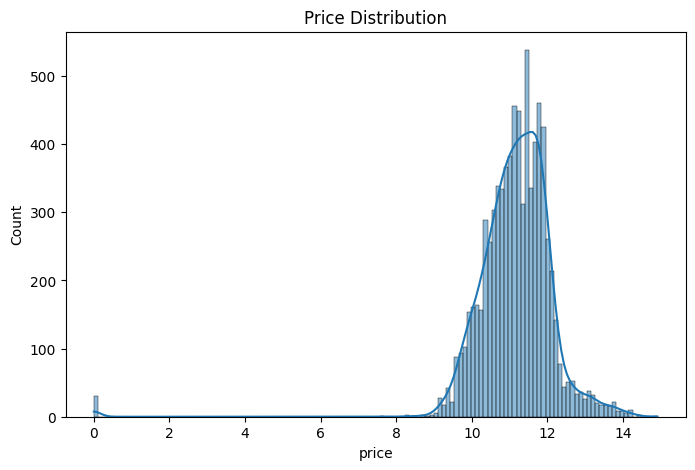

In [24]:
# Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

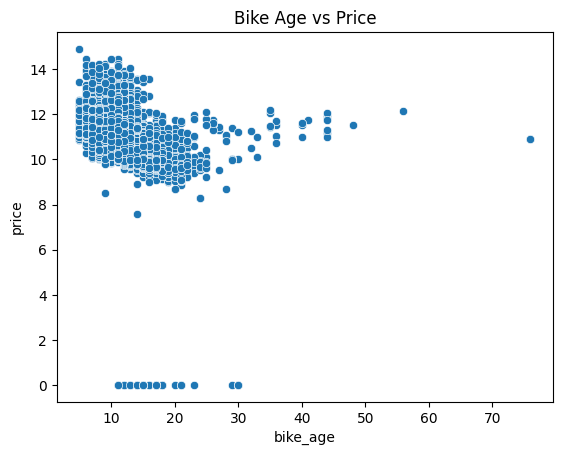

In [25]:
# Price vs Bike Age
sns.scatterplot(x=df['bike_age'], y=df['price'])
plt.title("Bike Age vs Price")
plt.show()

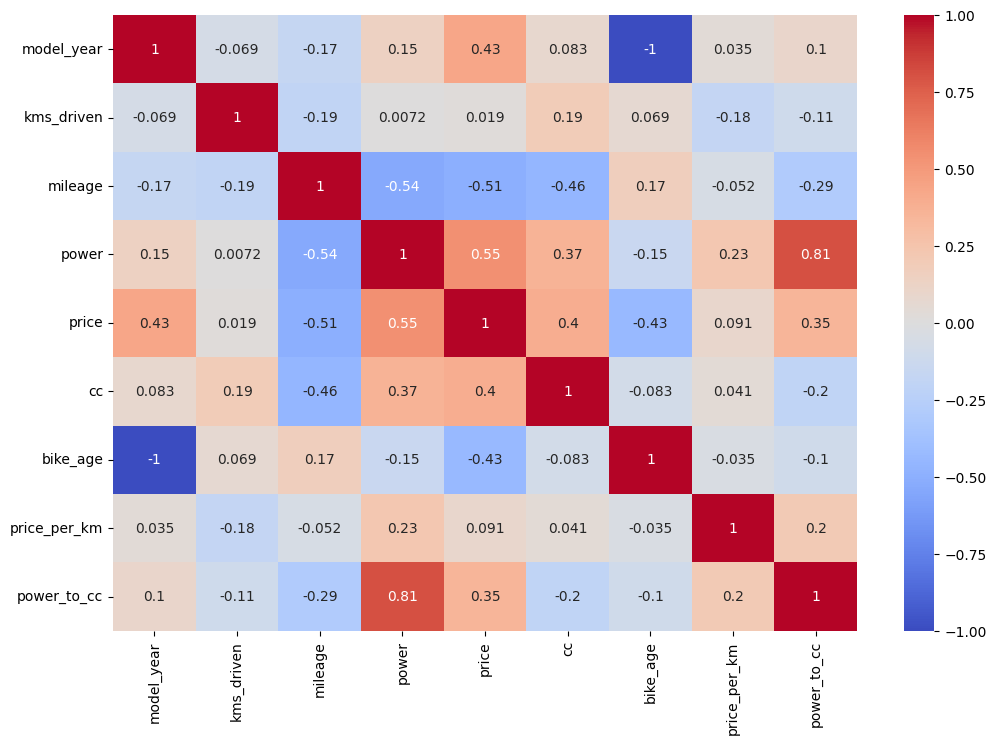

In [27]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)
plt.show()

In [28]:
# TRAIN TEST SPLIT
# Define features and target

X = df.drop(['price', 'model_name'], axis=1)
y = df['price']

# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
# SCALING
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
# MODEL TRAINING

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results)

# Show all results
print(results_df)

# Best model
best_model = results_df.loc[results_df['R2'].idxmax()]

print("\nBest Model:")
print(best_model)

               Model           MAE          RMSE            R2
0  Linear Regression  5.872356e+10  5.228204e+11 -1.948946e+23
1      Random Forest  9.127393e-02  2.244351e-01  9.640849e-01
2  Gradient Boosting  1.548681e-01  2.384951e-01  9.594441e-01

Best Model:
Model    Random Forest
MAE           0.091274
RMSE          0.224435
R2            0.964085
Name: 1, dtype: object


In [35]:
# HYPERPARAMETER TUNING
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [36]:
# FINAL EVALUATION
pred = best_model.predict(X_test)

print("Final Model Performance")
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test, pred))

Final Model Performance
MAE: 0.09173882794466555
RMSE: 0.2319057833590616
R2: 0.9616541791718358


In [37]:
# SAVE MODEL
import joblib

joblib.dump(best_model, "bike_price_model.pkl")

['bike_price_model.pkl']

# BUSINESS INSIGHTS

"""
1. New bikes have higher price
2. Higher CC bikes cost more
3. More kms driven reduces price
4. Brand plays major role in pricing
"""